# Naive Bayes: UCI HAR Dataset
**Dataset:** UCI HAR (ID: 240)  
**Module:** COMM075 Machine Learning for Data Science  
**Thread 1:** PyGoL vs Decision Tree vs Naive Bayes

Naive Bayes assumes **conditional independence** between features given the class. This is a strong assumption for sensor data where features are highly correlated — making it a useful baseline to compare against the relational PyGoL learner.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report)
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('outputs/nb_har', exist_ok=True)

train_df = pd.read_csv('ucihar_train.csv')
test_df  = pd.read_csv('ucihar_test.csv')

drop_cols = ['activity','subject','split']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['activity']
X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['activity']
activities = sorted(y_train.unique())

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

## 1. Model Training

In [2]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Gaussian Naive Bayes trained successfully")
print(f"Classes: {model.classes_}")

Gaussian Naive Bayes trained successfully
Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


## 2. Performance Metrics

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

acc  = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')
mcc  = matthews_corrcoef(y_test, y_pred)

y_test_bin = label_binarize(y_test, classes=activities)
roc_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')

print("=" * 28)
print("Naive Bayes Results")
print("=" * 28)
print(f"Accuracy           : {acc:.4f}")
print(f"Balanced Accuracy  : {bacc:.4f}")
print(f"Precision (macro)  : {prec:.4f}")
print(f"Recall (macro)     : {rec:.4f}")
print(f"F1 (macro)         : {f1:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"ROC-AUC (macro)    : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=activities))

Naive Bayes Results
Accuracy           : 0.7703
Balanced Accuracy  : 0.7691
Precision (macro)  : 0.7925
Recall (macro)     : 0.7691
F1 (macro)         : 0.7672
MCC                : 0.7286
ROC-AUC (macro)    : 0.9578

                    precision    recall  f1-score   support

            LAYING       0.96      0.60      0.74       537
           SITTING       0.58      0.75      0.65       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.82      0.84      0.83       496
WALKING_DOWNSTAIRS       0.83      0.61      0.70       420
  WALKING_UPSTAIRS       0.76      0.96      0.84       471

          accuracy                           0.77      2947
         macro avg       0.79      0.77      0.77      2947
      weighted avg       0.79      0.77      0.77      2947



## 3. Confusion Matrix

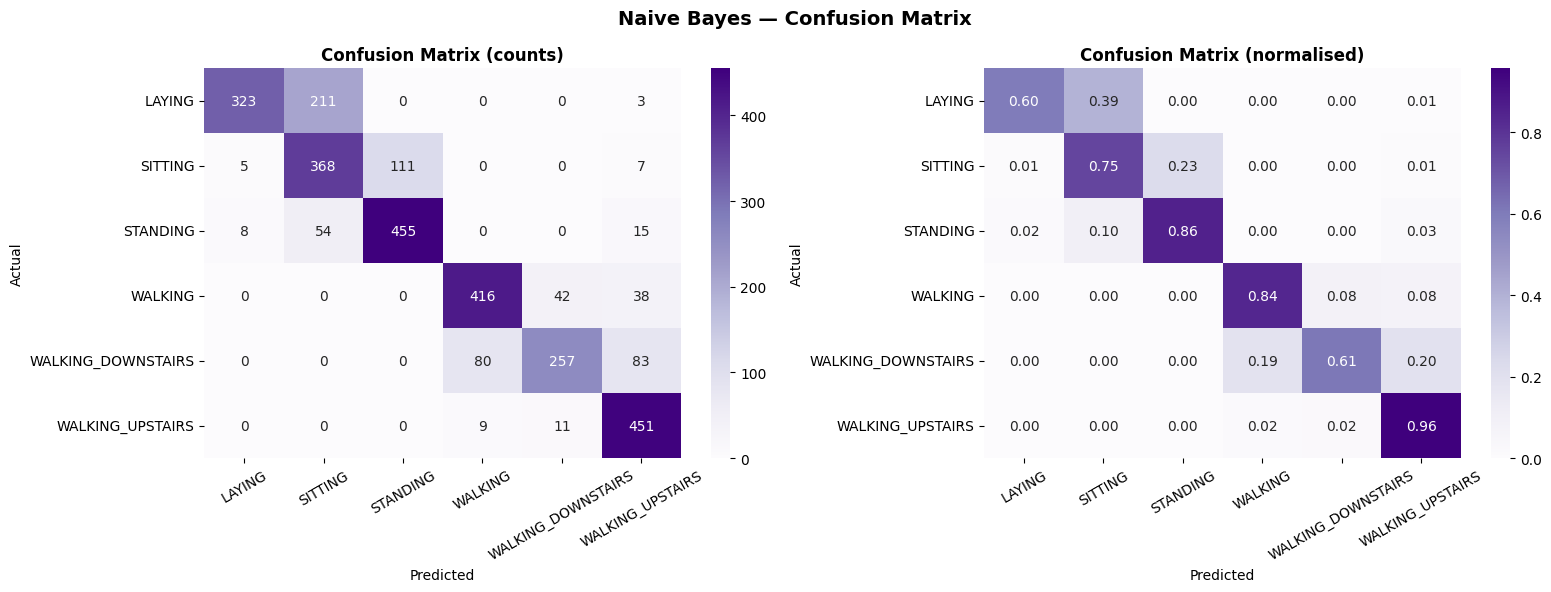

Saved: outputs/nb_har/01_confusion_matrix.png


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=activities)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=activities, yticklabels=activities)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples', ax=axes[1],
            xticklabels=activities, yticklabels=activities)
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Naive Bayes — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nb_har/01_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/nb_har/01_confusion_matrix.png")

## 4. Per-Activity Results

Activity                      Acc    Prec     Rec      F1
----------------------------------------------------------
LAYING                      0.601   0.961   0.601   0.740
SITTING                     0.749   0.581   0.749   0.655
STANDING                    0.855   0.804   0.855   0.829
WALKING                     0.839   0.824   0.839   0.831
WALKING_DOWNSTAIRS          0.612   0.829   0.612   0.704
WALKING_UPSTAIRS            0.958   0.755   0.958   0.845


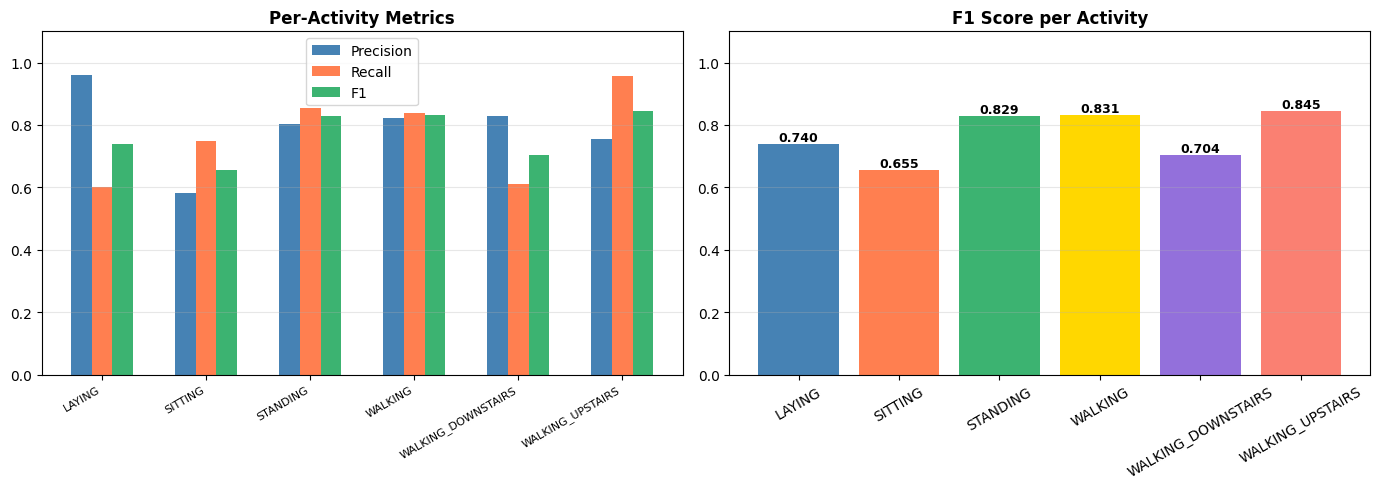

Saved: outputs/nb_har/nb_har_results.csv


In [8]:
prec_per = precision_score(y_test, y_pred, average=None, labels=activities)
rec_per  = recall_score(y_test, y_pred, average=None, labels=activities)
f1_per   = f1_score(y_test, y_pred, average=None, labels=activities)

results = []
print(f"{'Activity':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 58)
for i, act in enumerate(activities):
    acc_act = (y_test[y_test==act]==y_pred[y_test==act]).mean()
    print(f"{act:<25} {acc_act:>7.3f} {prec_per[i]:>7.3f} {rec_per[i]:>7.3f} {f1_per[i]:>7.3f}")
    results.append({'activity': act, 'accuracy': round(acc_act,4),
                    'precision': round(prec_per[i],4), 'recall': round(rec_per[i],4),
                    'f1': round(f1_per[i],4)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(activities))
w = 0.2
axes[0].bar(x-w, prec_per, w, label='Precision', color='steelblue')
axes[0].bar(x,   rec_per,  w, label='Recall',    color='coral')
axes[0].bar(x+w, f1_per,   w, label='F1',        color='mediumseagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(activities, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Per-Activity Metrics', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)

axes[1].bar(activities, f1_per, color=colors)
axes[1].set_title('F1 Score per Activity', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_per):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/nb_har/02_per_activity_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

res_df = pd.DataFrame(results)
res_df['algorithm'] = 'Naive Bayes'
res_df['roc_auc_overall'] = round(roc_auc, 4)
res_df.to_csv('outputs/nb_har/nb_har_results.csv', index=False)
print("Saved: outputs/nb_har/nb_har_results.csv")

## 5. Class Probability Analysis
Naive Bayes outputs probabilities for each class. High-confidence predictions (probabilities close to 1.0) indicate the model is certain; low-confidence indicates confusion between activities.

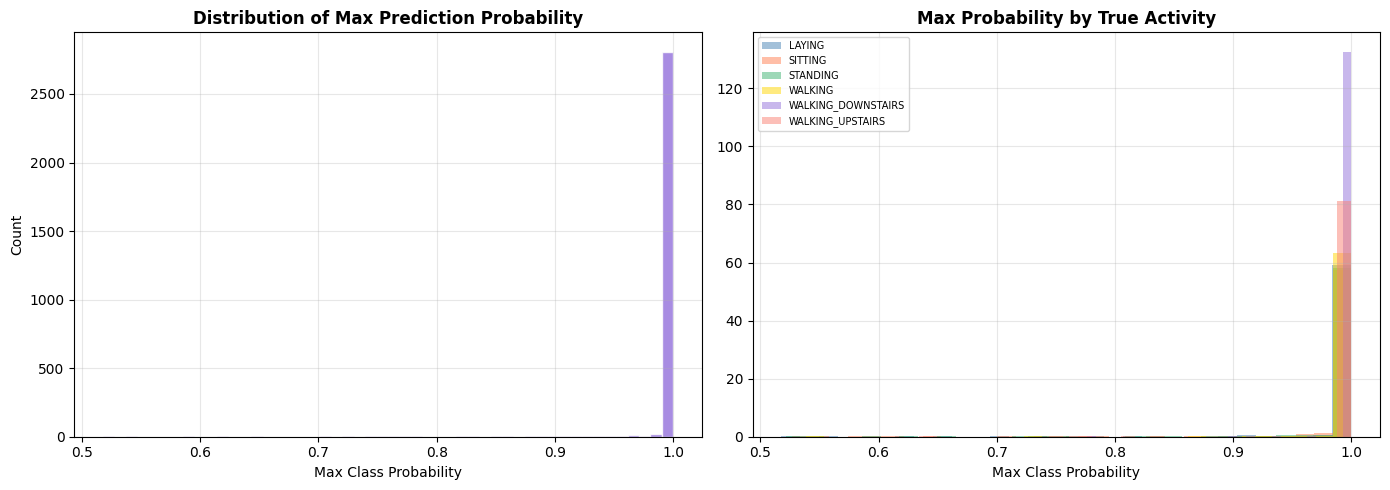

Mean confidence: 0.993
% high-confidence (>0.9): 97.9%
Saved: outputs/nb_har/03_probability_analysis.png


In [10]:
max_probs = y_prob.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(max_probs, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Max Prediction Probability', fontweight='bold')
axes[0].set_xlabel('Max Class Probability')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

for act, color in zip(activities, colors):
    mask = y_test == act
    axes[1].hist(max_probs[mask], bins=30, alpha=0.5, label=act, color=color, density=True)
axes[1].set_title('Max Probability by True Activity', fontweight='bold')
axes[1].set_xlabel('Max Class Probability')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/nb_har/03_probability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean confidence: {max_probs.mean():.3f}")
print(f"% high-confidence (>0.9): {(max_probs>0.9).mean()*100:.1f}%")
print("Saved: outputs/nb_har/03_probability_analysis.png")

## 6. ROC Curves (One-vs-Rest)

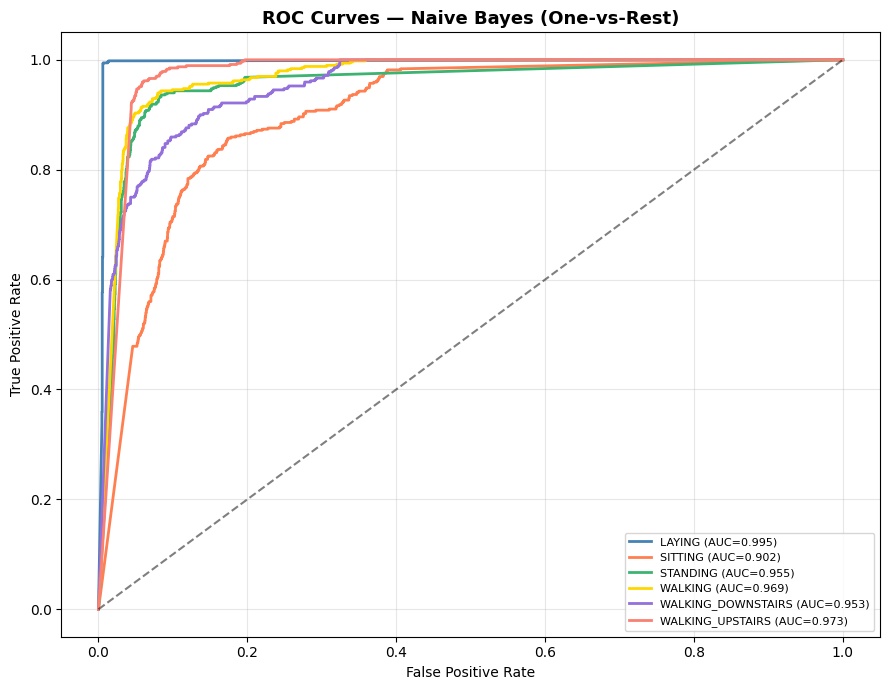

Saved: outputs/nb_har/04_roc_curves.png


In [12]:
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=activities)

fig, ax = plt.subplots(figsize=(9, 7))
for i, (act, color) in enumerate(zip(activities, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{act} (AUC={roc:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_title('ROC Curves — Naive Bayes (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/nb_har/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/nb_har/04_roc_curves.png")

## Summary

In [15]:
print("=" * 28)
print("FINAL RESULTS")
print("=" * 28)
print(f"Accuracy           : {acc:.4f}")
print(f"Balanced Accuracy  : {bacc:.4f}")
print(f"Macro Precision    : {prec:.4f}")
print(f"Macro Recall       : {rec:.4f}")
print(f"Macro F1           : {f1:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"ROC-AUC (macro)    : {roc_auc:.4f}")

print(f"\nOutput files saved to: outputs/nb_har/")

FINAL RESULTS
Accuracy           : 0.7703
Balanced Accuracy  : 0.7691
Macro Precision    : 0.7925
Macro Recall       : 0.7691
Macro F1           : 0.7672
MCC                : 0.7286
ROC-AUC (macro)    : 0.9578

Output files saved to: outputs/nb_har/
